# 1. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

# 2. Load the dataset (with features)

In [95]:
df = pd.read_csv("../data/BLE_FE.csv")
df = df.drop(columns='window_start')

In [96]:
df.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count,location
0,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
1,0,0,0,214,0,68,17,0,68,0,...,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9,kitchen
2,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7,cafeteria
3,0,0,0,68,0,0,0,0,0,0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9,cafeteria
4,0,0,0,136,17,0,34,0,47,0,...,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11,cafeteria


Text(0, 0.5, 'Count')

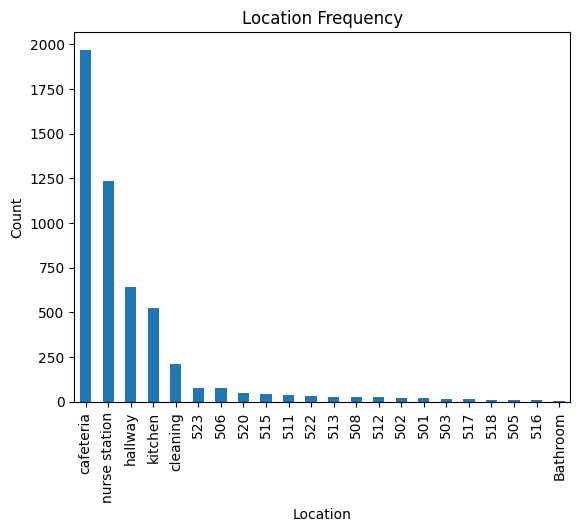

In [97]:
df['location'].value_counts().plot(kind='bar')
plt.title('Location Frequency')
plt.xlabel('Location')
plt.ylabel('Count')

In [98]:
print(df['location'].value_counts())

location
cafeteria        1970
nurse station    1234
hallway           644
kitchen           524
cleaning          212
523                77
506                75
520                46
515                43
511                35
522                33
513                27
508                27
512                26
502                22
501                19
503                12
517                12
518                10
505                 9
516                 8
Bathroom            6
Name: count, dtype: int64


In [99]:
percentages = df['location'].value_counts(normalize=True) * 100
print(percentages)

location
cafeteria        38.848353
nurse station    24.334451
hallway          12.699665
kitchen          10.333268
cleaning          4.180635
523               1.518438
506               1.478998
520               0.907119
515               0.847959
511               0.690199
522               0.650759
513               0.532439
508               0.532439
512               0.512719
502               0.433839
501               0.374680
503               0.236640
517               0.236640
518               0.197200
505               0.177480
516               0.157760
Bathroom          0.118320
Name: proportion, dtype: float64


In [100]:
y = df['location']

In [101]:
X = df.drop(columns='location')
X.head()

,count_1,count_2,count_3,count_4,count_5,count_6,count_7,count_8,count_9,count_10,...,b2_std,b2_max,b2_min,b2_norm,b3_mean,b3_std,b3_max,b3_min,b3_norm,unique_beacon_count
0,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
1,0,0,0,214,0,68,17,0,68,0,...,3.225366,-93.0,-101.0,796.197212,-94.0,1.007435,-93.0,-95.0,775.187719,9
2,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,7
3,0,0,0,68,0,0,0,0,0,0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,9
4,0,0,0,136,17,0,34,0,47,0,...,1.247755,-92.0,-95.0,640.694935,-95.0,3.045115,-92.0,-98.0,554.216564,11


In [102]:
split_idx = int(0.8 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y[:split_idx]
y_test  = y[split_idx:]

In [103]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
np.unique(y_train_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

In [104]:
y_test_encoded = le.transform(y_test)
np.unique(y_test_encoded)

array([ 3,  4,  5,  8,  9, 11, 12, 15, 16, 17, 18, 19, 20, 21])

In [105]:
class_counts = np.bincount(y_train_encoded)
class_freq = class_counts / class_counts.sum()

class_weights = {
    c: 1.0 / np.log(1.2 + class_freq[c])
    for c in range(len(class_counts))
}

sample_weights = np.array([class_weights[y] for y in y_train_encoded])

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [58]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,            
    min_samples_leaf=5,      
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

In [106]:
xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=15,   
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,        
    reg_lambda=2.0,
    objective="multi:softprob",
    tree_method="hist",
    random_state=42
)

In [ ]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", rf)
])
pipeline.fit(X_train, y_train_encoded)

In [107]:
pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])
pipeline.fit(X_train, y_train_encoded, classifier__sample_weight=sample_weights)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string 

In [112]:
y_pred = pipeline.predict(X_test)

In [115]:
probs = pipeline.predict_proba(X_test)

In [116]:
def confidence_smooth(probs, k):
    T, C = probs.shape
    smoothed = np.zeros_like(probs)
    conf = probs.max(axis=1)

    for t in range(T):
        start = max(0, t - k)
        end = min(T, t + k + 1)
        smoothed[t] = np.average(
            probs[start:end],
            axis=0,
            weights=conf[start:end]
        )

    return smoothed
k = 10
smoothed_probs = confidence_smooth(probs, k)
y_pred = smoothed_probs.argmax(axis=1)

In [117]:
accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='macro')

print(f"Accuracy: {accuracy:.2f}")
print(f"Macro F1 score: {f1:.2f}")

Accuracy: 0.59
Macro F1 score: 0.21


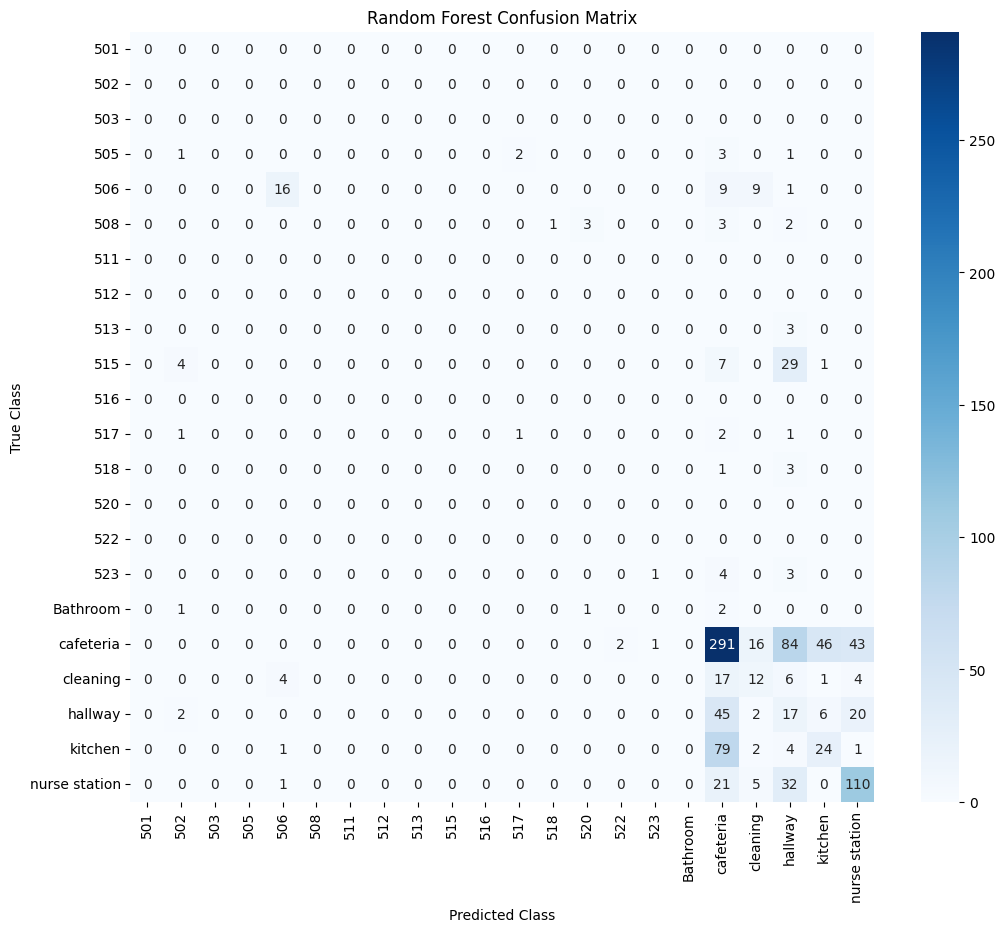

In [114]:
cm = confusion_matrix(y_test_encoded, y_pred, labels=range(len(le.classes_)))
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

In [ ]:
def rolling_time_splits(n_samples, splits):
    """
    splits: list of (train_frac, test_frac) tuples
    Example: [(0.6, 0.1), (0.7, 0.1), (0.8, 0.1)]
    """
    for train_frac, test_frac in splits:
        train_end = int(train_frac * n_samples)
        test_end = int((train_frac + test_frac) * n_samples)

        yield np.arange(0, train_end), np.arange(train_end, test_end)

splits = [
    (0.6, 0.1),
    (0.7, 0.1),
    (0.8, 0.1),
]

macro_f1_scores = []

for fold, (train_idx, test_idx) in enumerate(
    rolling_time_splits(len(X), splits), start=1
):
    print(f"\nFold {fold}")

    # --- Time-ordered split ---
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    # --- Label encoding (FIT ON TRAIN ONLY) ---
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train)

    # --- FILTER unseen labels in test set ---
    seen_classes = set(label_encoder.classes_)
    mask = y_test.isin(seen_classes)

    X_test_filt = X_test.loc[mask]
    y_test_filt = y_test.loc[mask]

    if len(y_test_filt) == 0:
        print("No test samples with seen labels — skipping fold")
        continue

    y_test_enc = label_encoder.transform(y_test_filt)

    # --- Compute log-scaled sample weights (XGBoost only) ---
    class_counts = np.bincount(y_train_enc)
    class_freq = class_counts / class_counts.sum()

    class_weights = {
        c: 1.0 / np.log(1.2 + class_freq[c])
        for c in range(len(class_counts))
    }

    sample_weights = np.array([class_weights[y] for y in y_train_enc])

    # --- Build pipeline ---
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_model)   # replace with rf for Random Forest
    ])

    # --- Fit model ---
    pipeline.fit(
        X_train,
        y_train_enc,
        classifier__sample_weight=sample_weights  # REMOVE for RF
    )

    # --- Predict probabilities (time-ordered) ---
    probs = pipeline.predict_proba(X_test_filt)

    # --- Temporal probability smoothing ---
    def smooth_probs(probs, k=3):
        T, C = probs.shape
        smoothed = np.zeros_like(probs)
        for t in range(T):
            start = max(0, t - k)
            end = min(T, t + k + 1)
            smoothed[t] = probs[start:end].mean(axis=0)
        return smoothed

    smoothed_probs = smooth_probs(probs, k=3)
    y_pred = smoothed_probs.argmax(axis=1)

    # --- Evaluate ---
    macro_f1 = f1_score(y_test_enc, y_pred, average="macro")
    macro_f1_scores.append(macro_f1)

    print(f"Fold {fold} macro-F1: {macro_f1:.4f}")
    print(f"Dropped {len(y_test) - len(y_test_filt)} unseen-label samples")

print("\nFinal results:")
print(f"Mean macro-F1: {np.mean(macro_f1_scores):.4f}")
print(f"Std macro-F1:  {np.std(macro_f1_scores):.4f}")


Fold 1
Fold 1 macro-F1: 0.2372

Fold 2


ValueError: y contains previously unseen labels: '505'